# Baseline simulation: bivariate VAR(4) with a decaying impulse response (Chapter 3)

This notebook implements the Chapter 3 baseline under **correct specification**. The data-generating
process (DGP) is a stable bivariate **VAR(4)** with recursive (Cholesky) identification. Against it we
compare two estimators of the structural impulse response (IRF) of variable 1 to the first structural
shock:

- a fixed **LP(4)** local projection, and
- a full **VAR(q) order sweep** for q = 1, …, p + H − 1 = 23.

Each estimator is scored against the known population IRF by Monte Carlo over 5,000 replications.
Mirroring Chapter 3, we report the **complexity frontier** (horizon-averaged RMSE against VAR order),
the **point-estimation metrics** (bias, variance, MSE, RMSE by horizon), and the **coverage** of
nominal 95% confidence intervals.

This file runs the **LOW** persistence scenario (ρ = 0.5). Sample sizes are swept over
T ∈ {100, 250, 500}.

In [16]:
# Standard scientific Python stack plus the project package `mcsim`
# (installed in editable mode via `pip install -e .`).
from functools import partial

import numpy as np
import matplotlib.pyplot as plt

# Project modules: DGP construction and true IRFs, the competing estimators,
# and the Monte Carlo driver.
from mcsim.dgp import VARSpec, simulate_var, var_irf, scale_to_persistence, spectral_radius
from mcsim.estimators import estimate_lp_irf, estimate_var_irf
from mcsim.simulation import MCConfig, run

## 0. Model parameters

The parameters below define the Chapter 3 baseline. They are fixed constants of the design and are
not tuned during the study. The only choice exposed to the user is the persistence **scenario**,
selected in the next cell, which maps to a target spectral radius $\rho$.

In [ ]:
# One of "LOW" (rho = 0.5), "MID" (rho = 0.7), or "HIGH" (rho = 0.95).
Scenario = "LOW"

SEED = 42                                     # master RNG seed, shared by every stochastic step
P = 4                                         # lag order of the baseline VAR DGP
H = 20                                        # maximum IRF horizon
N_REPS = 5000                                 # Monte Carlo replications per configuration
T = [100, 250, 500]                           # sample sizes swept in the study

# Map the scenario label to its target persistence (spectral radius of the companion matrix).
RHO_SCENARIO = {"LOW": 0.5, "MID": 0.7, "HIGH": 0.95}
RHO = RHO_SCENARIO[Scenario]

# Baseline VAR(4) coefficients. Geometrically decaying, symmetric lag matrices produce a smooth,
# monotonically decaying impulse response.
M = np.array([[0.50, 0.10], [0.10, 0.50]])    # symmetric, positive -> real, decaying response
A0 = np.array([M, 0.4 * M, 0.2 * M, 0.1 * M]) # unscaled lag matrices A1..A4
B = np.array([[1.0, 0.0], [0.5, 1.0]])        # recursive (lower-triangular) impact matrix

# Rescale the lag matrices so the companion spectral radius equals the target persistence RHO.
DGP = VARSpec(A=scale_to_persistence(A0, RHO), B=B)
print("achieved spectral radius (persistence):", round(spectral_radius(DGP.A), 3))

achieved spectral radius (persistence): 0.5


## 1. The data-generating process and its true impulse response

The lag matrices take the form $A_i = c^{\,i} M$ with $M$ symmetric and positive definite, which
yields a smooth, **monotonically decaying** response. We rescale the coefficients so that the
spectral radius of the companion matrix equals the target persistence $\rho$, and $B$ is
lower-triangular for recursive identification, exactly as specified in Chapter 3.

The figure below plots the **true** structural IRF, computed analytically from the DGP with no
estimation. The navy line is the estimand $\theta_h$, the response of $y_1$ to the first structural
shock $\varepsilon_1$. The grey line is the response of $y_2$ to the same shock. More persistent
scenarios decay more slowly.

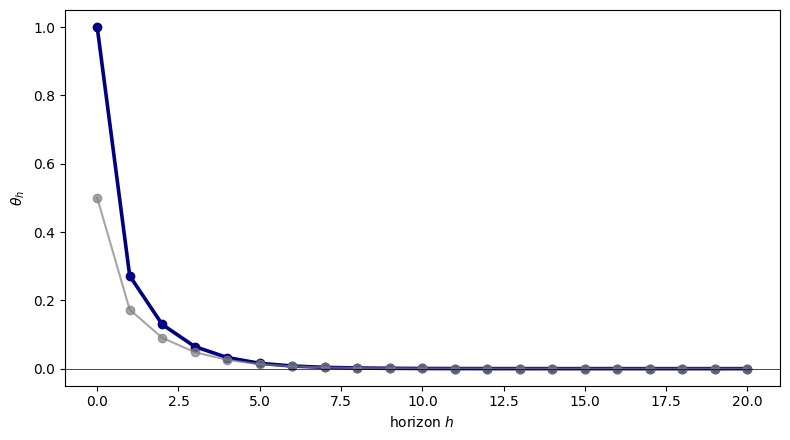

In [19]:
# Population (true) structural IRFs, computed directly from the DGP with no estimation.
# irf[(r, m)] is the response of variable r to structural shock m over horizons 0..H.
hgrid = np.arange(H + 1)
irf = {(r, m): var_irf(DGP, H, shock=m, response=r) for r in range(2) for m in range(2)}

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(hgrid, irf[(0, 0)], "o-", lw=2.6, color="navy",
        label=r"$y_1 \leftarrow \varepsilon_1$  (estimand $\theta_h$)")
ax.plot(hgrid, irf[(1, 0)], "o-", lw=1.5, alpha=0.7, color="tab:gray",
        label=r"$y_2 \leftarrow \varepsilon_1$")
ax.axhline(0, color="k", lw=0.5)
ax.set_xlabel("horizon $h$")
ax.set_ylabel(r"$\theta_h$")

# Figure titles are intentionally omitted here; captions are set in the LaTeX document.
fig.tight_layout()
plt.savefig(f"../../figures/Base_Case/BASE_IRF_rho={RHO}.png")
plt.show()

## 2. Monte Carlo: LP(4) and the VAR(q) sweep across sample sizes

We compare a fixed **LP(4)** against the full **VAR(q) sweep** ($q = 1, \dots, 23$), both under
recursive identification, running the Monte Carlo once **per sample size** $T \in \{100, 250, 500\}$.
The DGP and seed are held fixed across $T$, and the population estimand is $T$-independent, so any
difference across $T$ reflects finite-sample behaviour alone. For each $T$ we store the raw IRF draws
in `results_byT` and the horizon-wise RMSE in `rmse_byT`.

In [20]:
# Estimators under comparison, each presented as a one-argument callable `estimator(data) -> IRF`.
# `partial` binds the lag order and horizon so the driver can treat them interchangeably.
VAR_ORDERS = list(range(1, P + H))            # 1, 2, ..., 23

estimators = {"LP(4)": partial(estimate_lp_irf, p=P, horizon=H)}
estimators.update({f"VAR({q})": partial(estimate_var_irf, p=q, horizon=H) for q in VAR_ORDERS})


def var_dgp(rng, Tlen, spec):
    """DGP callable for the driver: simulate one VAR path of length Tlen."""
    return simulate_var(spec, Tlen, rng)


truth = var_irf(DGP, H)                        # population estimand (var1 <- shock1), T-independent

# Run the Monte Carlo once per sample size and record per-horizon RMSE for every estimator.
results_byT, rmse_byT = {}, {}
for Tval in T:
    cfg = MCConfig(n_reps=N_REPS, T=Tval, horizon=H, seed=SEED, n_jobs=-1,
                   progress=True, estimators=estimators)
    res = run(partial(var_dgp, spec=DGP), cfg)
    results_byT[Tval] = res
    rmse_byT[Tval] = {nm: np.sqrt(np.nanmean((st - truth) ** 2, axis=0))
                      for nm, st in res["irfs"].items()}
    fails = {k: v for k, v in res["n_failures"].items() if v}
    print(f"T={Tval:>4}: done  |  failures: {fails or 'none'}")

MC reps: 100%|██████████| 5000/5000 [00:12<00:00, 410.29it/s]


T= 100: done  |  failures: none


MC reps: 100%|██████████| 5000/5000 [00:16<00:00, 311.89it/s]


T= 250: done  |  failures: none


MC reps: 100%|██████████| 5000/5000 [00:20<00:00, 246.68it/s]


T= 500: done  |  failures: none


## 3. RMSE comparison across sample sizes

We summarise the sweep two ways. First the **complexity frontier**, the horizon-averaged RMSE against
VAR order, with one curve per $T$ and LP(4) drawn as a same-colour dashed reference line. Then a
summary table reporting LP(4), VAR(4), and the best-performing VAR order. As $T$ grows every estimator
improves and the curves compress toward the population LP = VAR equivalence.

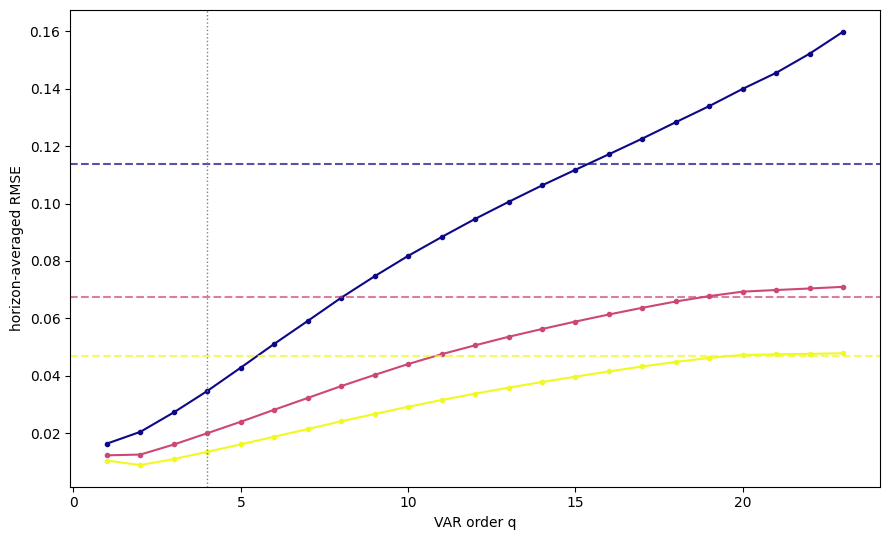

    T    LP(4)   VAR(4)       bestVAR   LP-VAR4
-----------------------------------------------
  100    0.114    0.035  VAR(1)=0.016    +0.079
  250    0.067    0.020  VAR(1)=0.012    +0.047
  500    0.047    0.014  VAR(2)=0.009    +0.033
(horizon-averaged RMSE;  LP-VAR4 > 0 = VAR(4) better)


In [21]:
# Colour each sample size consistently across plots.
cT = {Tval: plt.cm.plasma(i / max(len(T) - 1, 1)) for i, Tval in enumerate(T)}

# (1) Complexity frontier: horizon-averaged RMSE vs VAR order, one curve per sample size.
#     Solid line = VAR(q); dashed horizontal line = LP(4) reference in the same colour.
fig, ax = plt.subplots(figsize=(9, 5.5))
for Tval in T:
    rm = rmse_byT[Tval]
    avg_var = [np.mean(rm[f"VAR({q})"]) for q in VAR_ORDERS]
    ax.plot(VAR_ORDERS, avg_var, "o-", ms=3, color=cT[Tval], label=f"T={Tval}")
    ax.axhline(np.mean(rm["LP(4)"]), ls="--", color=cT[Tval], alpha=0.7)
ax.axvline(4, color="gray", ls=":", lw=1)     # equal-lag VAR(4) reference
ax.set_xlabel("VAR order q")
ax.set_ylabel("horizon-averaged RMSE")
fig.tight_layout()
plt.savefig(f"../../figures/Base_Case/BASE_COMPLEXITY_FRONTIER_rho={RHO}.png")
plt.show()

# (2) Summary table: horizon-averaged RMSE for LP(4), VAR(4), and the best VAR order.
#     LP-VAR4 > 0 means VAR(4) has the lower RMSE (the better point estimator).
print(f"{'T':>5} {'LP(4)':>8} {'VAR(4)':>8} {'bestVAR':>13} {'LP-VAR4':>9}")
print("-" * 47)
for Tval in T:
    rm = rmse_byT[Tval]
    lp = float(np.mean(rm["LP(4)"]))
    v4 = float(np.mean(rm["VAR(4)"]))
    avgs = {q: float(np.mean(rm[f"VAR({q})"])) for q in VAR_ORDERS}
    bq = min(avgs, key=avgs.get)               # VAR order with the lowest horizon-averaged RMSE
    print(f"{Tval:>5} {lp:8.3f} {v4:8.3f} {f'VAR({bq})={avgs[bq]:.3f}':>13} {lp - v4:+9.3f}")
print("(horizon-averaged RMSE;  LP-VAR4 > 0 = VAR(4) better)")

Interpretation depends on the persistence scenario, but the general pattern is that **VAR(4)
outperforms LP(4)** in horizon-averaged RMSE. The best VAR order, defined as the one with the lowest
horizon-averaged RMSE, is 1 or 2 under low persistence and 3 or 4 under medium to high persistence.
We also observe high-order VARs converging toward LP(4) performance once the sample size exceeds 250,
the finite-sample signature of the population equivalence.

## 4. Point-estimation metrics (Ch. 3)

Per horizon $h$, across $B$ replications, relative to the true estimand $\theta_h$:

$$\widehat{\mathrm{Bias}}_h=\tfrac1B\sum_b(\hat\theta_h^{(b)}-\theta_h),\quad
\widehat{\mathrm{Var}}_h=\tfrac1{B-1}\sum_b(\hat\theta_h^{(b)}-\bar{\hat\theta}_h)^2,\quad
\widehat{\mathrm{MSE}}_h=\tfrac1B\sum_b(\hat\theta_h^{(b)}-\theta_h)^2,\quad
\widehat{\mathrm{RMSE}}_h=\sqrt{\widehat{\mathrm{MSE}}_h}$$

with $\mathrm{MSE}_h=\mathrm{Bias}_h^2+\mathrm{Var}_h$ and Monte-Carlo standard error $\mathrm{MCSE}(\widehat{\mathrm{Bias}}_h)=\sqrt{\widehat{\mathrm{Var}}_h/B}$ to quantify simulation uncertainty. Shown at $T=250$ for LP(4), VAR(2), VAR(4), VAR(8), VAR(16), VAR(23).

*(The second Ch. 3 dimension — coverage of nominal 95% CIs, via the VAR(q) delta method and LP heteroskedasticity-robust SEs — needs per-replication interval machinery and is built separately.)*

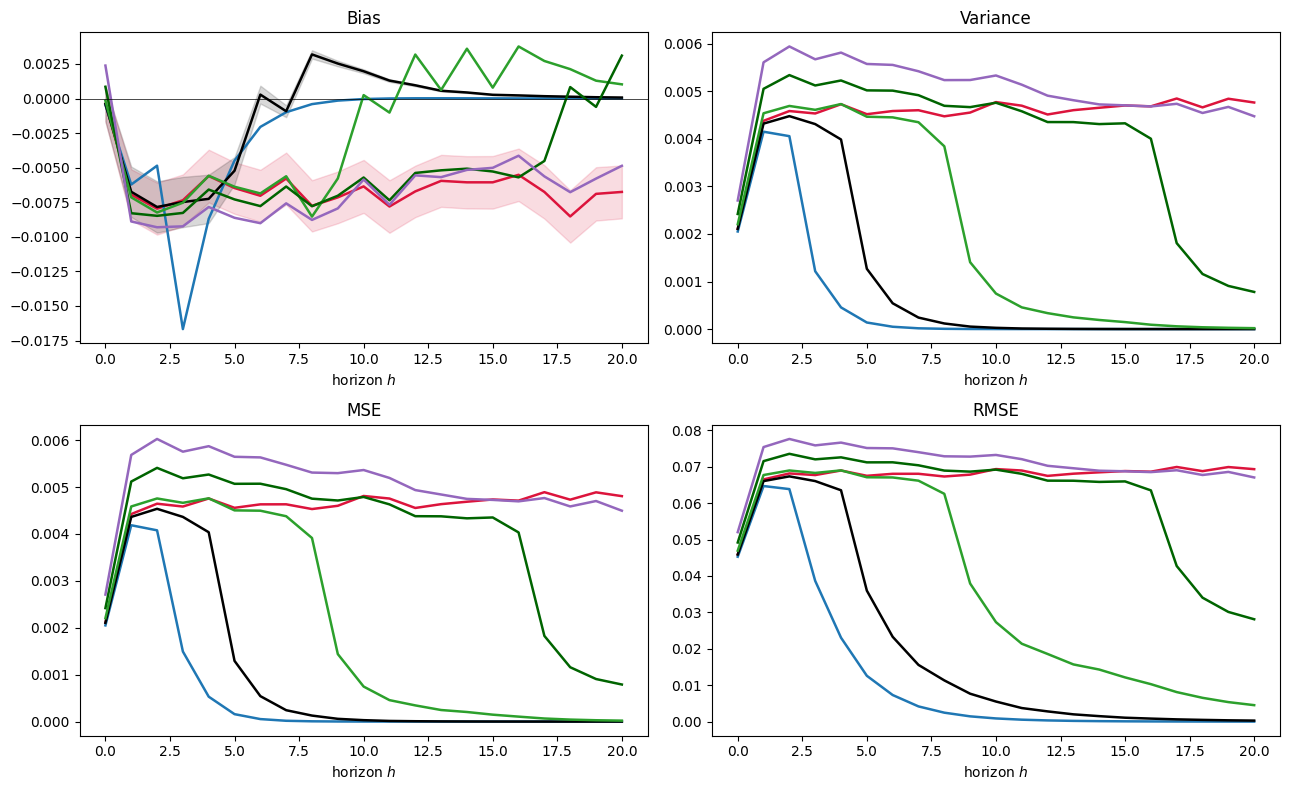

T=250,  B=5000   |   typical MCSE(bias) ~ 0.0004


h=1             h=8            h=20        
           bias    RMSE    bias    RMSE    bias    RMSE
LP(4)   -0.0070  0.0665 -0.0078  0.0673 -0.0068  0.0693
VAR(2)  -0.0062  0.0647 -0.0004  0.0025  0.0000  0.0000
VAR(4)  -0.0067  0.0661  0.0032  0.0113  0.0001  0.0003
VAR(8)  -0.0071  0.0677 -0.0085  0.0626  0.0010  0.0045
VAR(16) -0.0083  0.0715 -0.0078  0.0689  0.0031  0.0281
VAR(23) -0.0089  0.0754 -0.0088  0.0729 -0.0049  0.0671

In [25]:
import pandas as pd
from IPython.display import display

Tval = 250                                       # sample size shown in the point-estimation figure


def metrics(stack, truth):
    """Per-horizon Chapter 3 point metrics for a (B, H+1) stack of IRF estimates."""
    B = int(np.sum(~np.isnan(stack[:, 0])))
    mean = np.nanmean(stack, axis=0)
    bias = mean - truth
    var = np.nanvar(stack, axis=0, ddof=1)
    mse = np.nanmean((stack - truth) ** 2, axis=0)
    return dict(bias=bias, var=var, mse=mse, rmse=np.sqrt(mse),
                mcse_bias=np.sqrt(var / B), B=B)


# Estimators shown, with a fixed colour per estimator (reused in the coverage figure).
sel = ["LP(4)", "VAR(2)", "VAR(4)", "VAR(8)", "VAR(16)", "VAR(23)"]
colm = {"LP(4)": "crimson", "VAR(2)": "tab:blue", "VAR(4)": "black",
        "VAR(8)": "tab:green", "VAR(16)": "darkgreen", "VAR(23)": "tab:purple"}
m = {nm: metrics(results_byT[Tval]["irfs"][nm], truth) for nm in sel}

# Four-panel figure: bias, variance, MSE, RMSE by horizon.
fig, ax = plt.subplots(2, 2, figsize=(13, 8))
for nm in sel:
    ax[0, 0].plot(hgrid, m[nm]["bias"], color=colm[nm], lw=1.8, label=nm)
    ax[0, 1].plot(hgrid, m[nm]["var"], color=colm[nm], lw=1.8, label=nm)
    ax[1, 0].plot(hgrid, m[nm]["mse"], color=colm[nm], lw=1.8, label=nm)
    ax[1, 1].plot(hgrid, m[nm]["rmse"], color=colm[nm], lw=1.8, label=nm)

# Monte Carlo standard-error band on the bias (simulation uncertainty) for two reference estimators.
for nm in ("LP(4)", "VAR(4)"):
    lo = m[nm]["bias"] - 1.96 * m[nm]["mcse_bias"]
    hi = m[nm]["bias"] + 1.96 * m[nm]["mcse_bias"]
    ax[0, 0].fill_between(hgrid, lo, hi, color=colm[nm], alpha=0.15)

ax[0, 0].axhline(0, color="k", lw=0.5)
ax[0, 0].set_title("Bias")
ax[0, 1].set_title("Variance")
ax[1, 0].set_title("MSE")
ax[1, 1].set_title("RMSE")
for a in ax.ravel():
    a.set_xlabel("horizon $h$")
fig.tight_layout()
plt.savefig(f"../../figures/Base_Case/BASE_POINT_ESTIMATION_rho={RHO}_T={Tval}_B=5000.png")
plt.show()

# Compact table: bias and RMSE at selected horizons.
report = [1, 8, 20]
rows = {nm: {(f"h={h}", k): m[nm][{"bias": "bias", "RMSE": "rmse"}[k]][h]
             for h in report for k in ("bias", "RMSE")} for nm in sel}
tab = pd.DataFrame(rows).T
tab.columns = pd.MultiIndex.from_tuples(tab.columns)
print(f"T={Tval},  B={N_REPS}   |   typical MCSE(bias) ~ "
      f"{np.mean([m['VAR(4)']['mcse_bias'][h] for h in report]):.4f}")
display(tab.round(4))

## 5. Coverage of nominal 95% confidence intervals (Ch. 3)

The second Ch. 3 dimension. For each replication we build a 95% CI for $\theta_h$ and record whether it contains the **true** $\theta_h$; coverage is the fraction that do, $\widehat{\mathrm{Coverage}}_h=\tfrac1B\sum_b \mathbf 1[\theta_h\in \hat{CI}_h^{(b)}]$. A well-calibrated estimator gives ≈ 0.95 at every horizon.

Two CI constructions, exactly as Ch. 3 specifies:

* **VAR(q): delta method.** $\hat\theta_h=\hat\Psi_h\hat B e_1$ is a smooth function of the reduced-form coefficients $\hat A$. We propagate $\mathrm{Cov}(\hat A)$ through that map: $\mathrm{Var}(\hat\theta_h)\approx d_h'\,\Sigma_\alpha\,d_h$, where $d_h=\partial\theta_h/\partial\alpha$ comes from differentiating the MA recursion and $\Sigma_\alpha=\Sigma_u\otimes(X'X)^{-1}$ is the OLS coefficient covariance. Identification ($B$) is held fixed, as the thesis states ("propagating uncertainty in the reduced-form coefficients").
* **LP(4): heteroskedasticity-robust (HC) SE** of the shock coefficient $\hat\beta_h$. Plain White SE (not HAC) suffices because the structural shock is a martingale-difference regressor (Plagborg-Møller & Wolf).

We **validate** the delta method by checking its SE against the empirical sampling SD of $\hat\theta_h$ across replications — they should match.

coverage MC: 100%|██████████| 5000/5000 [01:12<00:00, 69.23it/s]


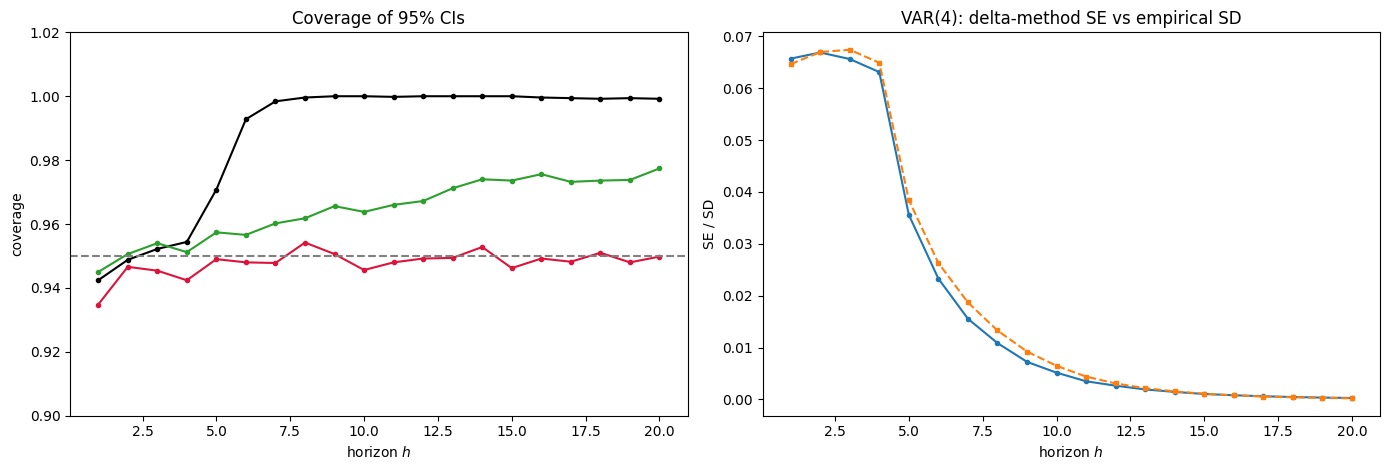

horizon-averaged coverage (h=1..20):  VAR(4)=0.988   VAR(23)=0.965   LP(4)=0.948


In [23]:
from joblib import Parallel, delayed
from tqdm import tqdm

from mcsim.coverage import var_theta_se, lp_theta_se

T_COV = 250            # single sample-size cell for the coverage study
N_COV = 5000           # replications for the coverage Monte Carlo
Z = 1.96               # normal critical value for a nominal 95% two-sided CI
EST_COV = ["VAR(4)", "VAR(23)", "LP(4)"]


def _coverage_rep(seed):
    """One replication: simulate a path, then return {estimator: (theta_hat, se)} by horizon."""
    rng = np.random.default_rng(seed)
    y = simulate_var(DGP, T_COV, rng)
    with np.errstate(divide="ignore", over="ignore", invalid="ignore"):
        return {
            "VAR(4)": var_theta_se(y, 4, H),
            "VAR(23)": var_theta_se(y, 23, H),
            "LP(4)": lp_theta_se(y, 4, H),
        }


# Independent, reproducible RNG stream per replication (parallel-safe), as in mcsim.run.
seeds = np.random.SeedSequence(SEED).spawn(N_COV)
reps_out = Parallel(n_jobs=-1)(delayed(_coverage_rep)(s) for s in tqdm(seeds, desc="coverage MC"))

# Stack per estimator: theta and se are (N_COV, H+1).
theta_s = {nm: np.array([r[nm][0] for r in reps_out]) for nm in EST_COV}
se_s = {nm: np.array([r[nm][1] for r in reps_out]) for nm in EST_COV}

# Coverage_h = fraction of CIs [theta_hat +/- Z*se] that contain the TRUE theta_h.
coverage = {nm: np.nanmean((theta_s[nm] - Z * se_s[nm] <= truth) &
                           (truth <= theta_s[nm] + Z * se_s[nm]), axis=0) for nm in EST_COV}

# Validation: the delta-method SE should match the empirical sampling SD of theta_hat.
val_emp = np.nanstd(theta_s["VAR(4)"], axis=0, ddof=1)
val_se = np.nanmean(se_s["VAR(4)"], axis=0)

# Left panel: coverage by horizon. Right panel: delta-method SE vs empirical SD for VAR(4).
fig, (axc, axv) = plt.subplots(1, 2, figsize=(14, 4.8))
cc = {"VAR(4)": "black", "VAR(23)": "tab:green", "LP(4)": "crimson"}
_ylo = float(max(0.0, np.floor((min(np.nanmin(coverage[nm][1:]) for nm in EST_COV) - 0.02) * 20) / 20))
for nm in EST_COV:
    axc.plot(hgrid[1:], coverage[nm][1:], "o-", ms=3, color=cc[nm], label=nm)
axc.axhline(0.95, color="gray", ls="--", label="nominal 0.95")
axc.set_ylim(_ylo, 1.02)
axc.set_xlabel("horizon $h$")
axc.set_ylabel("coverage")
axc.set_title("Coverage of 95% CIs")

axv.plot(hgrid[1:], val_emp[1:], "o-", ms=3, label="empirical SD of $\\hat\\theta_h$")
axv.plot(hgrid[1:], val_se[1:], "s--", ms=3, label="mean delta-method SE")
axv.set_xlabel("horizon $h$")
axv.set_ylabel("SE / SD")
axv.set_title("VAR(4): delta-method SE vs empirical SD")
fig.tight_layout()
plt.savefig(f"../../figures/Base_Case/BASE_COVERAGE_rho={RHO}_T=250_B=5000.png")
plt.show()

print(f"horizon-averaged coverage (h=1..{H}):  " +
      "   ".join(f"{nm}={np.nanmean(coverage[nm][1:]):.3f}" for nm in EST_COV))